In [76]:
import pandas as pd
df = pd.read_csv('classification.csv')
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [77]:
df['Dependents'].unique()

array(['0', '1', '2', '3+', nan], dtype=object)

In [78]:
df['Property_Area'].unique()

array(['Urban', 'Rural', 'Semiurban'], dtype=object)

In [79]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             601 non-null    object 
 2   Married            611 non-null    object 
 3   Dependents         599 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      582 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    object 
 12  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 62.5+ KB


In [80]:
df.drop('Loan_ID',axis=1,inplace=True)


In [81]:
df.duplicated().sum()

0

In [82]:
df.describe()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,614.000000,614.000000,592.000000,600.00000,564.000000
mean,5403.459283,1621.245798,146.412162,342.00000,0.842199
std,6109.041673,2926.248369,85.587325,65.12041,0.364878
min,150.000000,0.000000,9.000000,12.00000,0.000000
25%,2877.500000,0.000000,100.000000,360.00000,1.000000
50%,3812.500000,1188.500000,128.000000,360.00000,1.000000
75%,5795.000000,2297.250000,168.000000,360.00000,1.000000
max,81000.000000,41667.000000,700.000000,480.00000,1.000000


In [83]:
df.isnull().sum()

Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64

In [84]:
df.describe()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,614.000000,614.000000,592.000000,600.00000,564.000000
mean,5403.459283,1621.245798,146.412162,342.00000,0.842199
std,6109.041673,2926.248369,85.587325,65.12041,0.364878
min,150.000000,0.000000,9.000000,12.00000,0.000000
25%,2877.500000,0.000000,100.000000,360.00000,1.000000
50%,3812.500000,1188.500000,128.000000,360.00000,1.000000
75%,5795.000000,2297.250000,168.000000,360.00000,1.000000
max,81000.000000,41667.000000,700.000000,480.00000,1.000000


In [85]:
import numpy as np
df[df['LoanAmount']== 'nan']

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status


In [86]:
df['LoanAmount'] = df['LoanAmount'].fillna(df['LoanAmount'].median())

In [87]:
# z= df.select_dtypes('object').columns.drop(['Property_Area','Loan_Status']) 
mod_cols = list(df.select_dtypes(include='object').columns[df.select_dtypes(include='object').isnull().any()])
mod_cols.append('Credit_History')

for col in mod_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

In [88]:
df['LoanAmount'].mode()[0]

128.0

In [89]:
#if z in df.columns:
#    for z in df.columns:
#        df[z]=df[z].fillna(df[z].mode)
 #       print(df[z])

In [90]:
df['Loan_Amount_Term'].replace(12,df['Loan_Amount_Term'].mode()[0],inplace=True)
df['Loan_Amount_Term'].replace(36,df['Loan_Amount_Term'].mode()[0],inplace=True)
df['Loan_Amount_Term'] = df['Loan_Amount_Term'].fillna(df['Loan_Amount_Term'].mode()[0])

In [91]:
df.isnull().sum()

Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
Loan_Status          0
dtype: int64

In [92]:
df['total_income'] = df['ApplicantIncome'] + df['CoapplicantIncome']
df.drop(['CoapplicantIncome','ApplicantIncome'],axis= 1, inplace=True)

In [94]:
df.head()

,Gender,Married,Dependents,Education,Self_Employed,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status,total_income
0,Male,No,0,Graduate,No,128.0,360.0,1.0,Urban,Y,5849.0
1,Male,Yes,1,Graduate,No,128.0,360.0,1.0,Rural,N,6091.0
2,Male,Yes,0,Graduate,Yes,66.0,360.0,1.0,Urban,Y,3000.0
3,Male,Yes,0,Not Graduate,No,120.0,360.0,1.0,Urban,Y,4941.0
4,Male,No,0,Graduate,No,141.0,360.0,1.0,Urban,Y,6000.0


In [97]:
df['Dependents'].unique()

array([0, 1, 2, 3])

In [96]:
df['Dependents'] = df['Dependents'].replace('3+','3').astype(int)

In [98]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Gender            614 non-null    object 
 1   Married           614 non-null    object 
 2   Dependents        614 non-null    int32  
 3   Education         614 non-null    object 
 4   Self_Employed     614 non-null    object 
 5   LoanAmount        614 non-null    float64
 6   Loan_Amount_Term  614 non-null    float64
 7   Credit_History    614 non-null    float64
 8   Property_Area     614 non-null    object 
 9   Loan_Status       614 non-null    object 
 10  total_income      614 non-null    float64
dtypes: float64(4), int32(1), object(6)
memory usage: 50.5+ KB


In [116]:
df.select_dtypes('object').columns

Index(['Self_Employed', 'Property_Area', 'Loan_Status'], dtype='object')

In [100]:
def replacet(value):
    if value == 'No':
        return 0
    else:
        return 0
    
df['Married'] = df['Married'].apply(replacet)

In [102]:
df['Gender'] = df['Gender'].replace('Male',1)
df['Gender'].replace('Female',0,inplace=True)

In [105]:
df['Education'] = df['Education'].apply(lambda x:1 if x=='Graduate' else 0)

In [106]:
df['Education'].unique()

array([1, 0], dtype=int64)

In [122]:
dic = {'Y':1,
       'Urban':1,
        'Yes':1,
        'N':0,
        'Rural':0,
        'Semiurban':2,
        'No':0
       }

#df.select_dtypes('object').map(dict)
df['Loan_Status'] = df[ 'Loan_Status'].map(dic)

df['Property_Area'] = df[ 'Property_Area'].map(dic)

df['Self_Employed'] = df['Self_Employed'].map(dic)


In [123]:
df.head()

,Gender,Married,Dependents,Education,Self_Employed,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status,total_income
0,1,0,0,1,0,128.0,360.0,1.0,1,1,5849.0
1,1,0,1,1,0,128.0,360.0,1.0,0,0,6091.0
2,1,0,0,1,1,66.0,360.0,1.0,1,1,3000.0
3,1,0,0,0,0,120.0,360.0,1.0,1,1,4941.0
4,1,0,0,1,0,141.0,360.0,1.0,1,1,6000.0


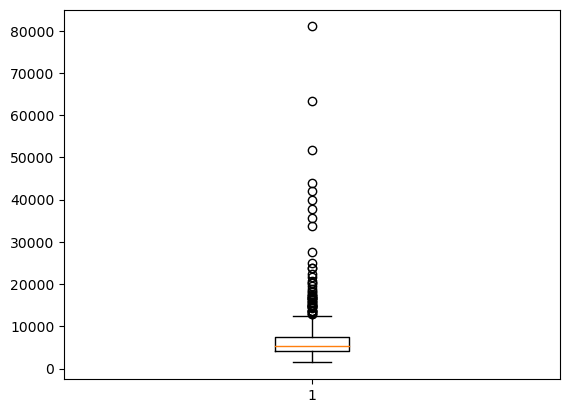

In [126]:
import matplotlib.pyplot as plt
plt.boxplot(df['total_income']);

In [127]:
Q1 = df['total_income'].quantile(0.25)
Q3 = df['total_income'].quantile(0.75)

IQR = Q3 - Q1 

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

df= df[(df['total_income'] >= lower_bound) & (df['total_income'] <= upper_bound)]

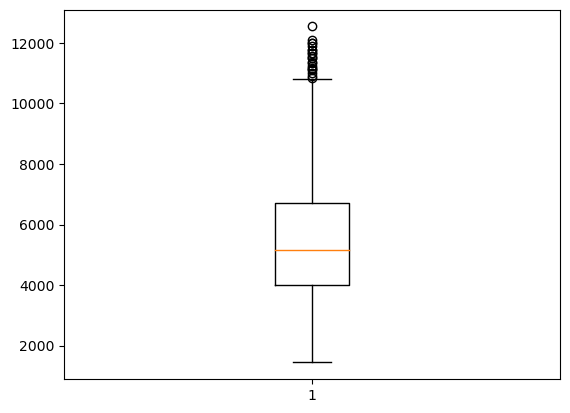

In [128]:
plt.boxplot(df['total_income']);

In [129]:
x = df.drop('Loan_Status',axis=1)
y= df['Loan_Status']

In [131]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y , test_size=0.2, random_state=42)
y_train.shape

(451,)

In [135]:
from sklearn.naive_bayes import MultinomialNB
naive = MultinomialNB()
naive.fit(x_train , y_train)


y_pred = naive.predict(x_test)
result = naive.score(x_test, y_test)
resut1  = naive.score(x_train, y_train )
print('score test is: ',result    , 'score train is: ',resut1)


score test is:  0.46017699115044247 score train is:  0.5144124168514412
